In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, pickle, time
warnings.filterwarnings('ignore')

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# Load Data
file_path = "/kaggle/input/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction/E Commerce Dataset.xlsx"
df = pd.read_excel(file_path, sheet_name='E Comm')

print("Shape:", df.shape)
df.head()

Shape: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


Churn Distribution:
Churn
0    4682
1     948
Name: count, dtype: int64
Churn
0    83.161634
1    16.838366
Name: proportion, dtype: float64


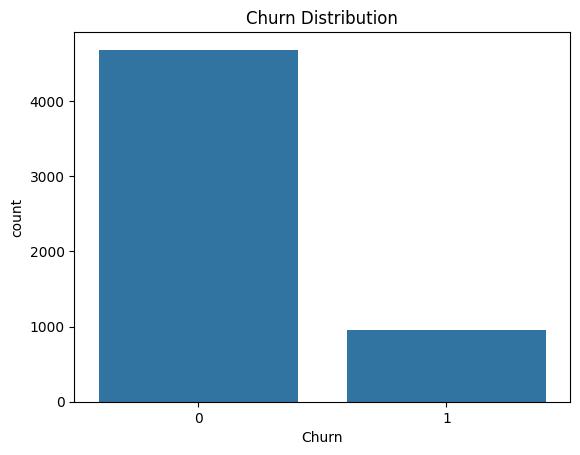

In [8]:
'''
    Here churn is our target variable and we understand the target variable distribution
'''

print("Churn Distribution:")
print(df['Churn'].value_counts())

churn_percent = df['Churn'].value_counts(normalize=True) * 100
print(churn_percent)

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()


In [3]:
print("\nMissing Values (%):")
missing = (df.isnull().sum() / len(df)) * 100
print(missing[missing > 0].sort_values(ascending=False))


Missing Values (%):
DaySinceLastOrder              5.452931
OrderAmountHikeFromlastYear    4.706927
Tenure                         4.689165
OrderCount                     4.582593
CouponUsed                     4.547069
HourSpendOnApp                 4.529307
WarehouseToHome                4.458259
dtype: float64


here missing value percent is low , so its best to impute using median which is resilient to outliers

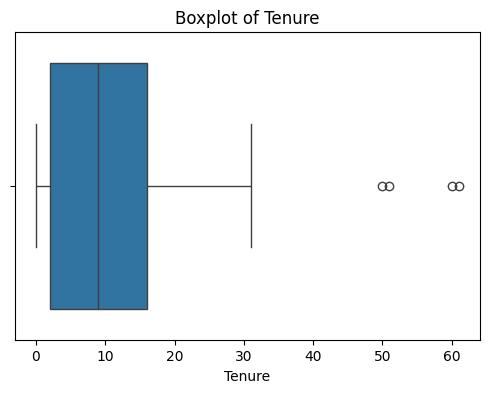

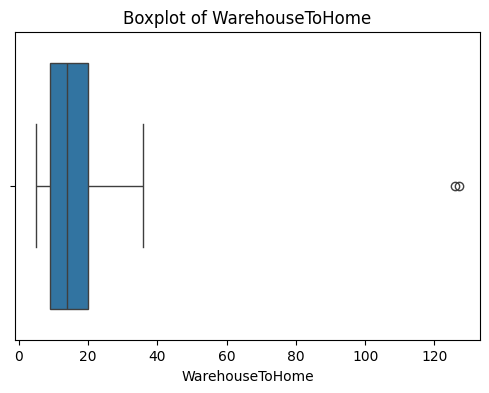

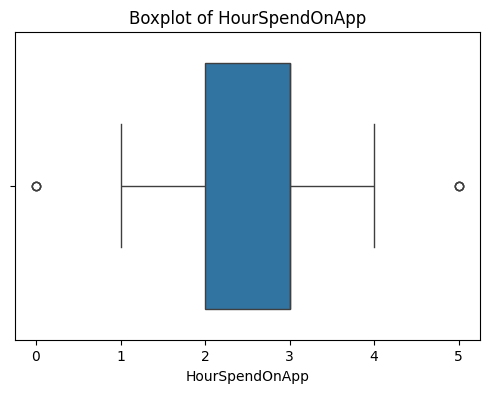

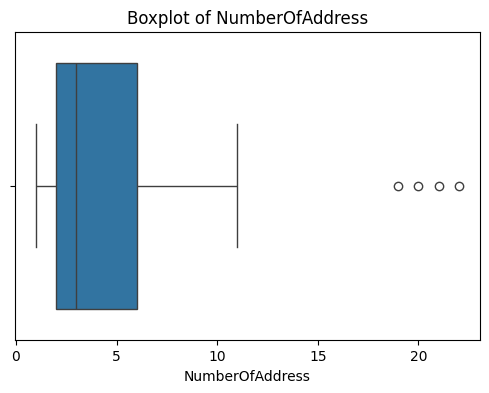

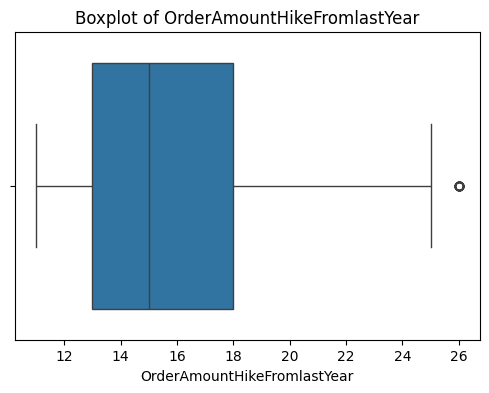

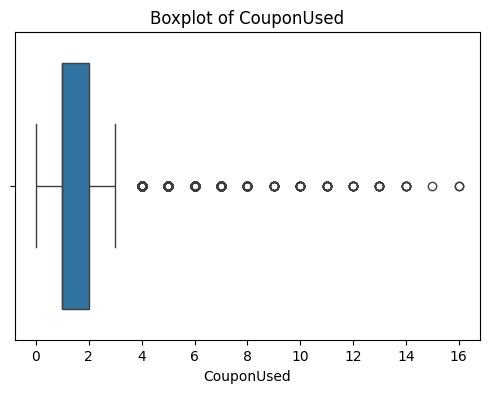

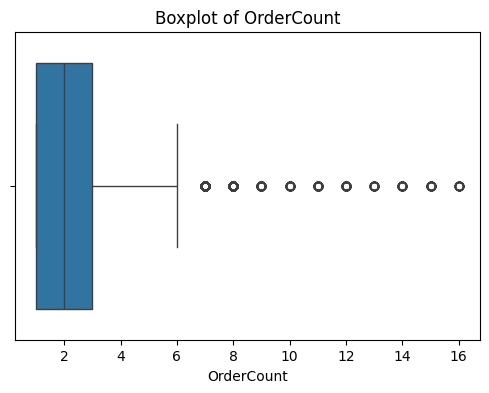

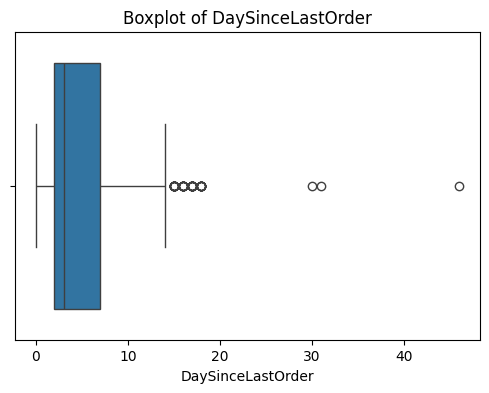

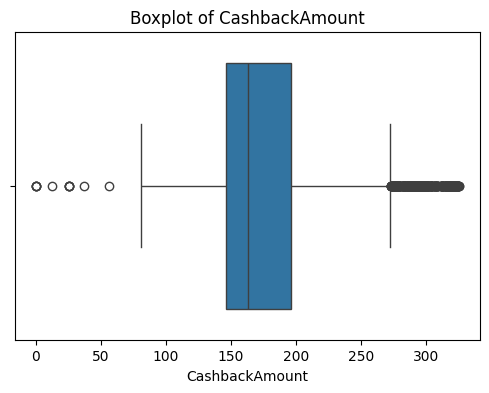

In [15]:
num_cols = ['Tenure','WarehouseToHome','HourSpendOnApp','NumberOfAddress',
            'OrderAmountHikeFromlastYear','CouponUsed','OrderCount',
            'DaySinceLastOrder','CashbackAmount']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [18]:
df_model = df.drop(columns=['CustomerID']) # customer id doesn't contribute to prediction

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=54
)

In [19]:
outlier_cols = [
    'Tenure','WarehouseToHome','NumberOfAddress',
    'OrderAmountHikeFromlastYear','CouponUsed',
    'OrderCount','DaySinceLastOrder','CashbackAmount'
]

bounds = {}

for col in outlier_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1 # interquantile range

    lo = Q1 - 1.5 * IQR
    hi = Q3 + 1.5 * IQR

    bounds[col] = (lo, hi)

    X_train[col] = X_train[col].clip(lo, hi)

# Outlier bounds are computed only on training data and then applied to test data to avoid data leakage.
for col in outlier_cols:
    lo, hi = bounds[col]
    X_test[col] = X_test[col].clip(lo, hi)

In [26]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = X.copy()

        X['tenure_bin'] = pd.cut(
            X['Tenure'],
            bins=[-1,0,3,12,24,100],
            labels=['new','early','mid','mature','loyal']
        )

        X['engagement_score'] = (X['HourSpendOnApp'] * X['OrderCount']) / (X['DaySinceLastOrder'] + 1) # +1 is added to avoid division by zero error
        X['coupon_ratio'] = X['CouponUsed'] / (X['OrderCount'] + 1)

        X['high_address_flag'] = (X['NumberOfAddress'] > 5).astype(int)
        X['inactive_flag'] = (X['DaySinceLastOrder'] > 10).astype(int)

        return X

In [22]:
num_cols_final = [
    'Tenure','WarehouseToHome','HourSpendOnApp','NumberOfDeviceRegistered',
    'SatisfactionScore','NumberOfAddress','OrderAmountHikeFromlastYear',
    'CouponUsed','OrderCount','DaySinceLastOrder','CashbackAmount','CityTier',
    'engagement_score','coupon_ratio'
]

cat_cols_final = [
    'PreferredLoginDevice','PreferredPaymentMode',
    'PreferedOrderCat','MaritalStatus','Gender','tenure_bin'
]

bin_cols_final = ['Complain','high_address_flag','inactive_flag']

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, num_cols_final),
    ('cat', categorical_pipe, cat_cols_final),
    ('bin', 'passthrough', bin_cols_final)
])

In [24]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000), #Predicts probability of churn using a linear combination of features.
    "Random Forest": RandomForestClassifier(n_estimators=200), #Uses multiple decision trees and takes majority vote for prediction.
    "SVM": SVC(probability=True), #Finds the best boundary that separates churn and non-churn customers.
    "XGBoost": XGBClassifier(eval_metric='logloss') #Builds trees sequentially, each correcting the previous one’s mistakes.
}

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    pipe = Pipeline([
        ('fe', FeatureEngineer()),
        ('prep', preprocessor),
        ('model', model)
    ])

    scores = cross_validate(
        pipe, X_train, y_train,
        cv=cv,
        scoring=['accuracy','precision','recall','f1']
    )

    results.append({
        "Model": name,
        "Accuracy": scores['test_accuracy'].mean(),
        "Precision": scores['test_precision'].mean(),
        "Recall": scores['test_recall'].mean(),
        "F1": scores['test_f1'].mean()
    })

results_df = pd.DataFrame(results).sort_values(by='F1', ascending=False)
print(results_df)

                 Model  Accuracy  Precision    Recall        F1
3              XGBoost  0.961590   0.917477  0.848257  0.881304
1        Random Forest  0.949825   0.923642  0.765188  0.836721
2                  SVM  0.914744   0.853266  0.596349  0.701439
0  Logistic Regression  0.888987   0.731435  0.538332  0.620026


In [31]:
best_model_name = results_df.iloc[0]['Model']
print("Best Model:", best_model_name)
if best_model_name == "XGBoost":
    model = XGBClassifier(eval_metric='logloss')
    param_grid = {
        'model__n_estimators': [200, 350],
        'model__max_depth': [4, 6],
        'model__learning_rate': [0.05, 0.1]
    }

elif best_model_name == "Random Forest":
    model = RandomForestClassifier()
    param_grid = {
        'model__n_estimators': [200, 300],
        'model__max_depth': [None, 10]
    }

elif best_model_name == "Logistic Regression":
    model = LogisticRegression(max_iter=1000)
    param_grid = {
        'model__C': [0.1, 1, 10]
    }

elif best_model_name == "SVM":
    model = SVC(probability=True)
    param_grid = {
        'model__C': [0.1, 1, 10],
        'model__kernel': ['linear', 'rbf']
    }

pipe = Pipeline([
    ('fe', FeatureEngineer()),
    ('prep', preprocessor),
    ('model', model)
])

# Grid Search - find the best hyperparameters for the best-performing model
gs = GridSearchCV(pipe, param_grid, cv=cv, scoring='f1', n_jobs=-1)
gs.fit(X_train, y_train)

best_pipeline = gs.best_estimator_

print("Best Params:", gs.best_params_)

Best Model: XGBoost
Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 350}


True Positive (TP)
Customer actually churned, and we correctly predicted churn

True Negative (TN)
Customer did not churn, and we correctly predicted no churn

False Positive (FP)
Customer did not churn, but we wrongly predicted churn

False Negative (FN)
Customer actually churned, but we wrongly predicted no churn

In [32]:
y_pred = best_pipeline.predict(X_test)
y_prob = best_pipeline.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test,y_pred))
#(TP + TN) / Total -> Out of all customers, how many did we predict correctly?
print("Precision:", precision_score(y_test,y_pred)) 
# TP / (TP + FP) -> Out of all customers we predicted as churn, how many actually churned?
print("Recall:", recall_score(y_test,y_pred)) 
# TP / (TP + FN) -> Out of all actual churn customers, how many did we successfully identify?
print("F1:", f1_score(y_test,y_pred)) 
# 2 * (Precision * Recall) / (Precision + Recall) -> How well does the model balance precision and recall?
print("ROC-AUC:", roc_auc_score(y_test,y_prob)) 
# How well does the model rank churn customers higher than non-churn customers?

print("\nClassification Report:")
print(classification_report(y_test,y_pred))

Accuracy: 0.9822380106571936
Precision: 0.9473684210526315
Recall: 0.9473684210526315
F1: 0.9473684210526315
ROC-AUC: 0.9908850652271706

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       936
           1       0.95      0.95      0.95       190

    accuracy                           0.98      1126
   macro avg       0.97      0.97      0.97      1126
weighted avg       0.98      0.98      0.98      1126



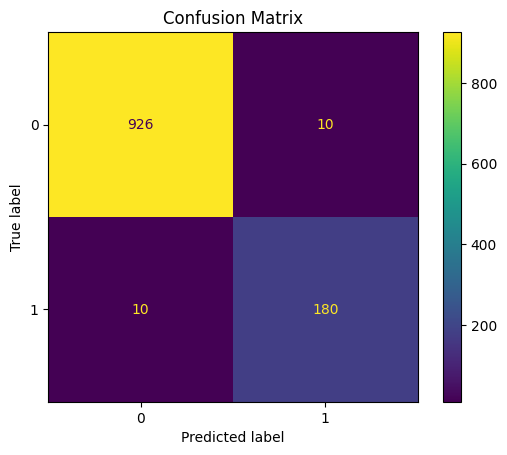

In [33]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix") 
#                 Predicted
#               0        1
# Actual  0     TN       FP
#         1     FN       TP

plt.show()

In [34]:
os.makedirs("models", exist_ok=True)

with open("models/churn_model.pkl","wb") as f:
    pickle.dump(best_pipeline,f)

print("Model saved successfully")

Model saved successfully


Top 5 Important Features:
                                     Feature  Importance
0                                num__Tenure    0.150428
34                             bin__Complain    0.069169
23  cat__PreferedOrderCat_Laptop & Accessory    0.044546
28                 cat__MaritalStatus_Single    0.042194
9                     num__DaySinceLastOrder    0.035634


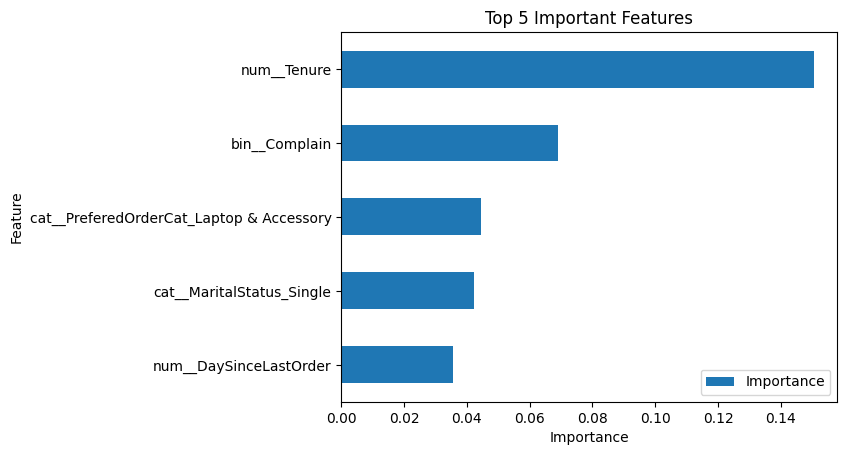

In [36]:
feature_names = best_pipeline.named_steps['prep'].get_feature_names_out()

model = best_pipeline.named_steps['model']

importances = model.feature_importances_

import pandas as pd

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

#Get Top 5 features
top5_features = feature_importance_df.sort_values(
    by='Importance', ascending=False
).head(5)

print("Top 5 Important Features:")
print(top5_features)


#Plot Top 5 features
import matplotlib.pyplot as plt

top5_features.sort_values(by='Importance').plot(
    x='Feature', y='Importance', kind='barh'
)
plt.title("Top 5 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()